## Compare the Power Spectrum, Bispectrum, and Scattering Transform of a 2D Turbulence Simulation ##
**J.W.Skinner, Caltech, 2024**

This notebook demonstrates the information contained in the power spectrum, bispectrum, and scattering transform of a 2D turbulence simulation. This is done by synthesizing an image by gradient descent from each of the three statistics and comparing them to the original image.

In [7]:
%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
import torch
import torch.fft
import netCDF4 as nc
from scipy.ndimage import zoom
import time
import sys
sys.path.append('/home/jskinner1/scattering_transform')
import scattering
import ST
importlib.reload(ST)
import math

### Import data and structure it for the ST analysis

In [8]:
# Clear cache and import data 
torch.cuda.empty_cache()

# ------- Input data ------
datapath = "./JWS_turb_data/"
imin = 90  # starting index
imax = 100  # ending index
device = 'gpu'

with nc.Dataset(datapath + f"output_0{imin:03d}.nc", "r") as file:
    nx = file.dimensions["nx"].size
    ny = file.dimensions["nx"].size

image = np.zeros(((imax - imin + 1), nx, ny))

for i in range(imin, imax):
    filename = datapath + f"output_0{i:03d}.nc"  
    with nc.Dataset(filename, "r") as file:
        z = file.variables["z"][:]
        image[i - imin] = z

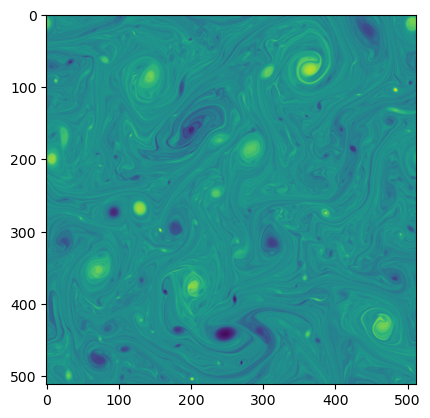

In [9]:
# Choose target image frame to synthesize 
target_index = 0
target_image = image[target_index]
plt.imshow(target_image)

### Synthesis

#### Power Spectrum

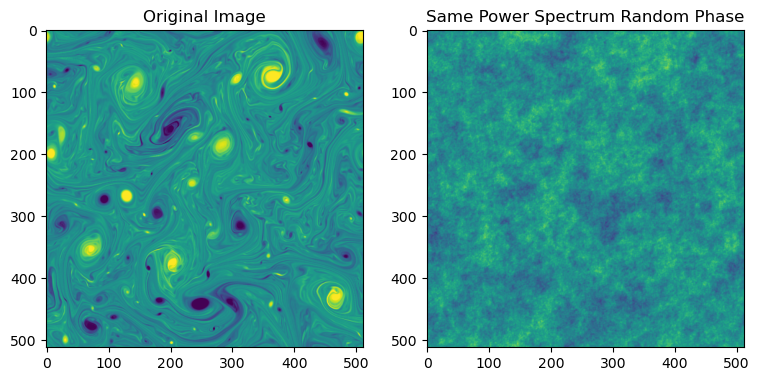

In [10]:
# 1. Power Spectrum Synthesis

# Fourier Transform of the target
fft_data = np.fft.fft2(target_image)

# Extract the Magnitude
magnitude = np.abs(fft_data)

# Generate Random Phases
random_phase = np.random.uniform(-np.pi, np.pi, magnitude.shape)

# Recombine Magnitude and Random Phase
new_fft_data = magnitude * np.exp(1j * random_phase)

# Inverse FFT to get back to the spatial domain
synthesized_image_power = np.fft.ifft2(new_fft_data).real

# Plot
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(target_image, vmin = -0.25, vmax = 0.25)
axes[0].set_title("Original Image")
axes[1].imshow(synthesized_image_power, vmin = -0.25, vmax = 0.25)
axes[1].set_title("Same Power Spectrum Random Phase")
plt.show()

#### Bispectrum

In [11]:
# Function for image synthesis using gradient descent
def image_synthesis(image, 
                    J, 
                    L, 
                    num_pixel,
                    learnable_param_list=[(100, 1e-3)],
                    coef='ST',
                    random_seed=987, 
                    epsilon = 1e-8, 
                    clipping = False):

    from collections import defaultdict
    loss_history = defaultdict(list) # collect loss info

    # Set random seeds
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

    # set device for torch 
    if torch.cuda.is_available():
        print("Using CUDA")
        device = torch.device('cuda')
    else:
        print("Warning: No GPU found. Falling back to CPU.")
        device = torch.device('cpu')

    # Prepare Target Image
    image_np = image[:num_pixel, :num_pixel]
    image_torch = torch.from_numpy(image_np).float().to(device)
    
    # Pre-compute Base Targets
    target_L1 = (image_torch).abs().mean()
    target_mean = image_torch.mean()

    print(target_L1)
    # Pre-compute Targets for Loss
    if coef in ['bi', 'bi+P']:
        target_bi = bispectrum_calculator.forward(image_torch)
        target_PS, _ = ST.get_power_spectrum(image_torch, 20, device)
        target_PS_log = torch.log(target_PS + epsilon)
    if coef == 'ST':
        target_ST_raw = ST_calculator.forward(image_torch.unsqueeze(0), J, L)[0][0]
        st_mask = (target_ST_raw != 0) 
        target_ST = target_ST_raw[st_mask].log()

    # Learnable Parameter (Gaussian Random Field)
    init_data = ST.get_random_data(image_np, num_pixel, num_pixel, "image") # generates a gaussian random field with the same power spectrum as the target
    image_to_train = torch.from_numpy(init_data).float().to(device)
    
    # Parameter
    param = torch.nn.Parameter(image_to_train)

    optimizer = torch.optim.Adamax([param], lr=learnable_param_list[0][1])

    # Optimization
    for phase_idx, (num_step, learning_rate) in enumerate(learnable_param_list):
        
        for g in optimizer.param_groups:
            g['lr'] = learning_rate

        for i in range(int(num_step)):
            optimizer.zero_grad()

            # --- Base Losses ---
            mean_weight = 1e0 
            L1_weight = 1e0 
            loss_L1 = (((param).abs().mean() - target_L1) / target_L1)**2 * mean_weight
            loss_mean = (param.mean() - target_mean)**2 * mean_weight

            loss =  loss_mean + loss_L1 
            
            # Initialize metrics with base values
            log_metrics = {'mean': loss_mean.item(), 'L1': loss_L1.item()}

            # --- Descriptor Losses ---
            if coef == 'bi':
                bi = bispectrum_calculator.forward(param)
                loss_bi = ((target_bi - bi)**2).sum()
                loss += loss_bi
                log_metrics['bi'] = loss_bi.item()

            elif coef == 'bi+P':
                # Bispectrum loss 
                bi = bispectrum_calculator.forward(param)
                loss_bi = ((target_bi - bi)**2).sum() # sum error
                #loss_bi = (((target_bi - bi)**2).mean() / (target_bi.abs().mean()**2)) #MSE
                
                # Power Spectrum loss
                PS, _ = ST.get_power_spectrum(param, 20, device)
                PS_log = torch.log(PS + epsilon)
                loss_PS = ((target_PS_log - PS_log)**2).sum()
                #loss_PS = ((target_PS_log - PS_log)**2).mean() / (target_PS_log.abs().mean()**2 + epsilon)
                
                weight_PS = 0.0 # PS not needed in loss, field is intialized with same PS and preserves it.
                weight_bi = 1.0e0
                loss += (weight_bi * loss_bi) + (weight_PS * loss_PS)
                log_metrics['bi'] = weight_bi * loss_bi.item()
                log_metrics['PS'] = weight_PS * loss_PS.item()

            elif coef == 'ST':
                weight_st = 1e0
                ST_coef_raw = ST_calculator.forward(param.unsqueeze(0), J, L)[0][0]
                ST_coef = ST_coef_raw[st_mask] 
                ST_coef = torch.clamp(ST_coef, min=1e-8).log()
                
                #loss_ST = ((target_ST - ST_coef)**2).sum() # sum
                loss_ST = ((target_ST - ST_coef)**2).mean() / (target_ST.abs().mean()**2 + epsilon) #norm mean
                loss += weight_st * loss_ST
                log_metrics['ST'] = weight_st * loss_ST.item()

            # --- Total Loss ---
            log_metrics['loss'] = loss.item()

            # --- Logging ---
            if i % 100 == 0:
                print(f"Step {i:04d} | " + " | ".join([f"{k}: {v:.4e}" for k, v in log_metrics.items()]))

            for key, val in log_metrics.items():
                loss_history[key].append(val)

            # --- Backpropogation ---
            loss.backward()
            if clipping:
                torch.nn.utils.clip_grad_norm_([param], max_norm=0.5) # apply gradient clipping
            optimizer.step()

    return param.unsqueeze(0).detach().cpu().numpy(), dict(loss_history)

def plot_synthesis(target_img, synth_img, device, vmin=-0.25, vmax=0.25, filename=None, epsilon=1e-8):
    
    synth_img_2d  = synth_img[0]  if synth_img.ndim == 3  else synth_img
    target_img_2d = target_img[0] if target_img.ndim == 3 else target_img

    plt.figure(figsize=(14, 3))
    
    # 1. Target Image
    plt.subplot(141)
    plt.imshow(target_img_2d, vmin=vmin, vmax=vmax)
    plt.title('Target Image')
    plt.xticks([])
    plt.yticks([])
    
    # 2. Synthesized Image
    plt.subplot(142)
    plt.imshow(synth_img_2d, vmin=vmin, vmax=vmax)
    plt.title('Synthesized Image')
    plt.xticks([])
    plt.yticks([])

    # 3. Histograms
    plt.subplot(143)
    y, x = np.histogram(target_img_2d, 100, (vmin, vmax))
    plt.plot((x[1:] + x[:-1]) / 2, y, label='target')
    y, x = np.histogram(synth_img_2d, 100, (vmin, vmax))
    plt.plot((x[1:] + x[:-1]) / 2, y, label='synthesized')
    plt.legend()
    plt.yscale('log')
    plt.title('Pixel Intensity Histogram')

    # 4. Power Spectrum
    plt.subplot(144)
    target_torch = torch.from_numpy(target_img_2d).float().to(device)
    synth_torch  = torch.from_numpy(synth_img_2d).float().to(device)
    with torch.no_grad():
        target_PS, target_k = ST.get_power_spectrum(target_torch, 20, device)
        synth_PS,  _        = ST.get_power_spectrum(synth_torch,  20, device)
    k_np = (target_k.cpu().numpy()[:-1] + target_k.cpu().numpy()[1:]) / 2
    plt.loglog(k_np, target_PS.cpu().numpy(), label='target')
    plt.loglog(k_np, synth_PS.cpu().numpy(),  label='synthesized', linestyle='--')
    plt.ylim(bottom=1e-5)
    plt.xlabel('k')
    plt.ylabel('Power')
    plt.title('Power Spectrum')
    plt.legend()
    
    plt.tight_layout()
    
    if filename is not None:
        if not filename.lower().endswith('.pdf'):
            filename += '.pdf'
        plt.savefig(filename, format='pdf', bbox_inches='tight')
        
    plt.show()
    
    print(f"Target STD: {target_img_2d.std():.5f} | Synth STD: {synth_img_2d.std():.5f}")
    print(f"Target Mean: {target_img_2d.mean():.5f} | Synth Mean: {synth_img_2d.mean():.5f}")

def plot_losses(loss_history):
    """Plots the optimization loss curves over iterations."""
    plt.figure(figsize=(9, 3))
    tracked_components = ['PH00', 'S1', 'C01', 'PH11diag', 'PH11', 'mean', 'L1', 'ST', 'bi', 'PS']
    
    for key in tracked_components:
        if key in loss_history and len(loss_history[key]) > 0:
            plt.plot(loss_history[key], label=key, linestyle='-')
            
    total_key = 'total' if 'total' in loss_history else 'loss'
    if total_key in loss_history:
        plt.plot(loss_history[total_key], label='Total Loss', color='black', linestyle='--', linewidth=2.0)
        
    plt.yscale('log') 
    plt.ylim(bottom=1e-16)
    plt.xlabel('Evaluations')
    plt.ylabel('Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)
    plt.tight_layout()
    plt.show()

Using CUDA
tensor(0.0361, device='cuda:0')


/home/jskinner1/miniconda3/envs/be/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647406761/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Step 0000 | mean: 1.3553e-20 | L1: 6.4996e-02 | bi: 3.2855e+08 | PS: 0.0000e+00 | loss: 3.2855e+08
Step 0100 | mean: 5.0491e-07 | L1: 2.1120e-02 | bi: 1.2431e+03 | PS: 0.0000e+00 | loss: 1.2431e+03
Step 0200 | mean: 5.0583e-07 | L1: 2.1135e-02 | bi: 9.7253e+01 | PS: 0.0000e+00 | loss: 9.7274e+01
Step 0300 | mean: 5.0598e-07 | L1: 2.1142e-02 | bi: 2.6225e+01 | PS: 0.0000e+00 | loss: 2.6246e+01
Step 0400 | mean: 5.0603e-07 | L1: 2.1145e-02 | bi: 8.2352e+00 | PS: 0.0000e+00 | loss: 8.2563e+00
Step 0000 | mean: 5.0605e-07 | L1: 2.1146e-02 | bi: 2.3365e+00 | PS: 0.0000e+00 | loss: 2.3576e+00
Step 0100 | mean: 5.0605e-07 | L1: 2.1146e-02 | bi: 2.0481e+00 | PS: 0.0000e+00 | loss: 2.0692e+00
Step 0200 | mean: 5.0605e-07 | L1: 2.1146e-02 | bi: 1.7717e+00 | PS: 0.0000e+00 | loss: 1.7928e+00
Step 0300 | mean: 5.0605e-07 | L1: 2.1146e-02 | bi: 1.5091e+00 | PS: 0.0000e+00 | loss: 1.5303e+00
Step 0400 | mean: 5.0605e-07 | L1: 2.1146e-02 | bi: 1.2638e+00 | PS: 0.0000e+00 | loss: 1.2849e+00


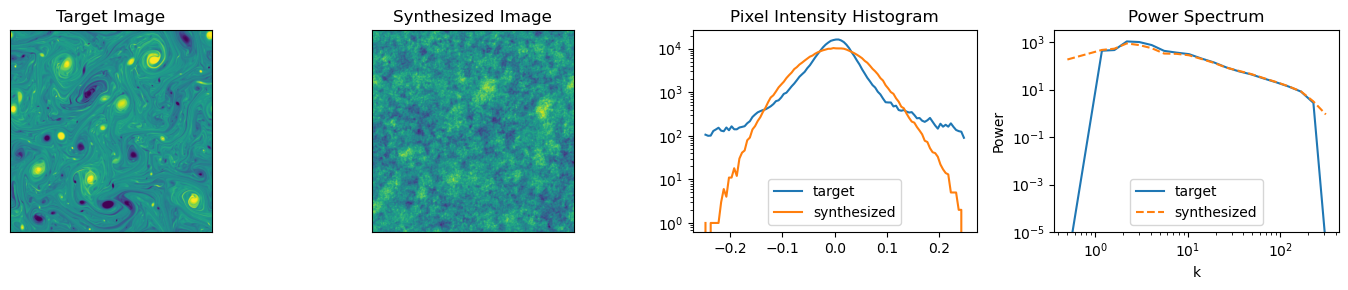

Target STD: 0.05722 | Synth STD: 0.05234
Target Mean: 0.00000 | Synth Mean: -0.00071


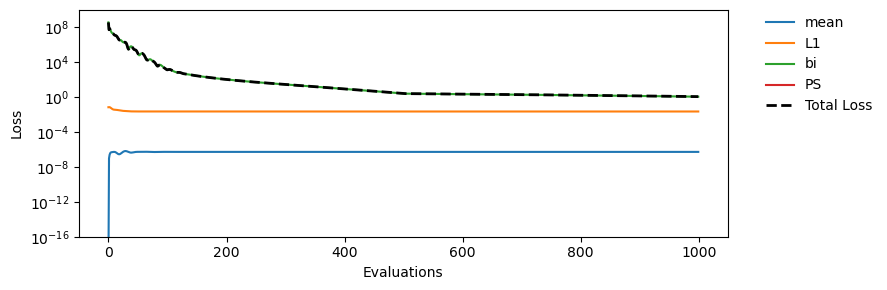

In [12]:
# 2. Bispectrum + Power Spectrum Synthesis
M, N = target_image.shape
J = 8
L = 4

# Bispectrum Calculator
bin_edges = np.logspace(np.log2(1), np.log2(M / 2), J + 1, base=2)
bispectrum_calculator = ST.Bispectrum_Calculator(bin_edges, M, N, device=device)
image_torch = torch.from_numpy(target_image)
if device=='gpu':
  image_torch = image_torch.cuda()
torch.set_num_threads(1) 
start = time.time()
B = bispectrum_calculator.forward(image_torch)

# Perform Synthesis
synthesized_image_bi, loss_bi = image_synthesis(
    target_image, 
    J=J, 
    L=L, 
    num_pixel=M,
    learnable_param_list = [  
    (500, 1e-2),  
    (500, 1e-3),  
    ],
    coef = 'bi+P',
    random_seed = 987
)

plot_synthesis(target_image, synthesized_image_bi, vmin=-0.25, vmax=0.25, device=torch.device('cuda'))
plot_losses(loss_bi)

#### Scattering Transform

Using CUDA
tensor(0.0361, device='cuda:0')
Step 0000 | mean: 1.3553e-20 | L1: 6.4996e-02 | ST: 2.8781e-02 | loss: 9.3777e-02
Step 0100 | mean: 2.9957e-08 | L1: 1.5739e-07 | ST: 3.7624e-03 | loss: 3.7626e-03
Step 0200 | mean: 1.0801e-08 | L1: 8.1924e-09 | ST: 3.4936e-03 | loss: 3.4936e-03
Step 0000 | mean: 5.2389e-09 | L1: 1.7905e-09 | ST: 3.3978e-03 | loss: 3.3978e-03
Step 0100 | mean: 4.9212e-09 | L1: 1.3958e-09 | ST: 3.3917e-03 | loss: 3.3917e-03
Step 0200 | mean: 4.6032e-09 | L1: 1.1741e-09 | ST: 3.3854e-03 | loss: 3.3854e-03


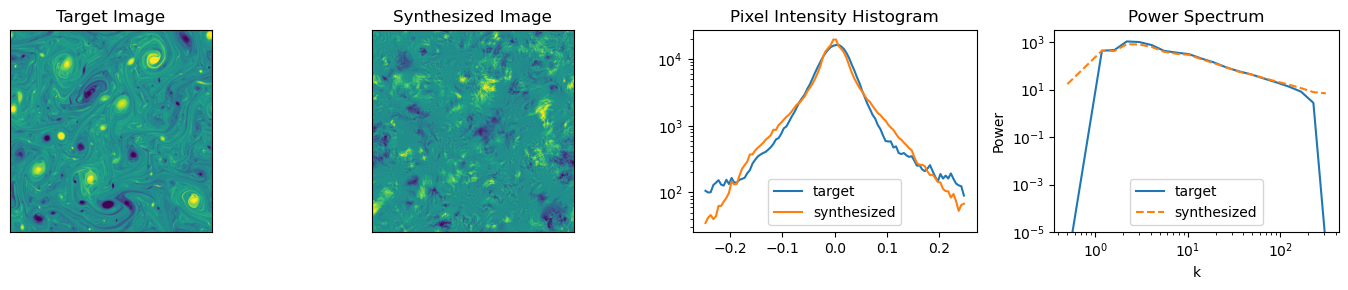

Target STD: 0.05722 | Synth STD: 0.05504
Target Mean: 0.00000 | Synth Mean: -0.00007


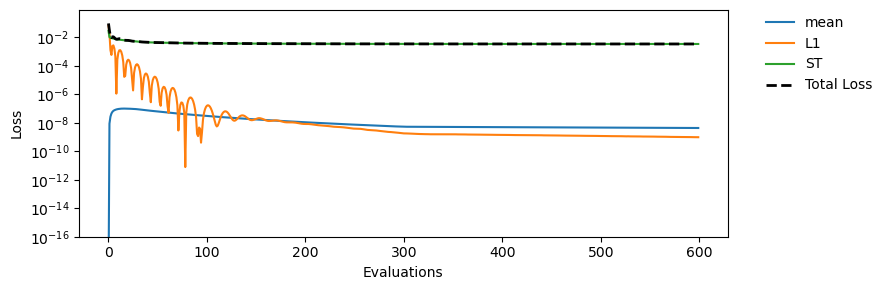

In [13]:
# 3. ST Synthesis
M, N = target_image.shape
J = 8
L = 4

# ST Calculator
filters_set = ST.FiltersSet(M=M, N=N, J=J, L=L).generate_morlet(
    if_save=False, save_dir=None, precision='single'
)
ST_calculator = ST.ST_2D(filters_set, J, L, device=device)
image_torch = torch.from_numpy(target_image)[None,:,:]
if device=='gpu':
  image_torch = image_torch.cuda()
torch.set_num_threads(2) 
start = time.time()
S = ST_calculator.forward(image_torch, J, L)[0]

# synthesis
synthesized_image_st, loss_st = image_synthesis(
        target_image, 
        J=J, 
        L=L, 
        num_pixel=M,
        learnable_param_list = [  
            (300, 1e-2),
            (300, 1e-3),    
            ],
        coef = 'ST',
        random_seed = 987, 
    )
    
plot_synthesis(target_image, synthesized_image_st, vmin=-0.25, vmax=0.25, device=torch.device('cuda'))
plot_losses(loss_st)

#### Scattering Transform + Phase Harmonics derived from scattering coefficients

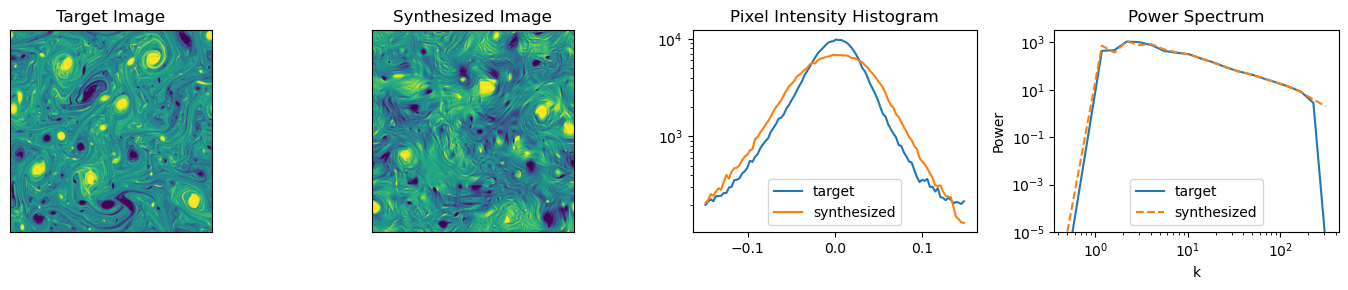

Target STD: 0.05722 | Synth STD: 0.05781
Target Mean: 0.00000 | Synth Mean: 0.00000


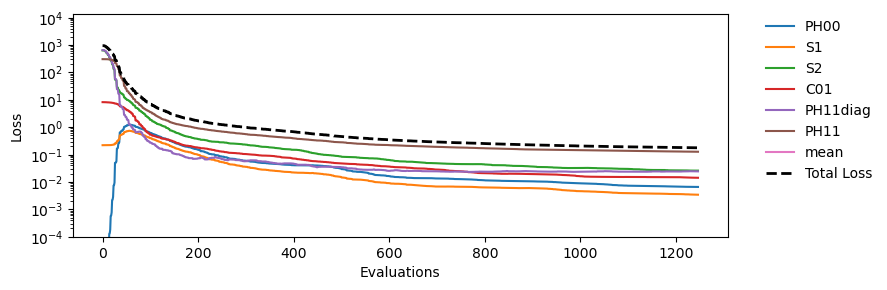

Done. Target STD: 0.057216828106191164 | Synth STD: 0.05781484395265579


In [15]:
from IPython.display import clear_output

def image_synthesis_PH(
    image, J, L,
    N_realization=1,
    learnable_param_list=[(100, 1e-3)],
    device='cpu',
    random_seed=987,
    starting_power_factor=1.0,
    starting_image=None,
    ST_algorithm='fast',
    ):
    
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

    N_image = image.shape[0]
    M = image.shape[1]
    N = image.shape[2]

    # ST calculator with Morlet wavelets
    filters_set = ST.FiltersSet(M=M, N=N, J=J, L=L).generate_morlet(if_save=False, save_dir=None, precision='single')
    ST_calculator = ST.ST_2D(filters_set, J, L, device=device)

    image_torch = torch.from_numpy(image).type(torch.FloatTensor)

    if device == 'gpu':
        image_torch = image_torch.cuda()

    # Target Scattering Coeficients
    target_ST_all = ST_calculator.forward(
        image_torch, 
        J, 
        L,
        algorithm=ST_algorithm,
        pseudo_coef=1,
    )
    target_mean = target_ST_all[0][:, 0]
    target_S2 = target_ST_all[3] 
    target_S2_flat = target_S2.reshape(N_image, -1)
    select_S2 = (target_S2_flat[0] > 0)
    target_S2_flat = target_S2_flat[:, select_S2]

    # Target Phase harmonics
    target_PH_all = ST_calculator.phase_harmonics(image_torch, J, L)

    target_C01 = target_PH_all['C01_r']
    select_C01 = (target_C01[0] != 0)
    target_C01 = target_C01[:, select_C01]

    target_PH00 = target_PH_all['C00'].sum(-1)
    target_S1 = target_PH_all['S1'].sum(-1)

    target_PH11diag = target_PH_all['C11diag_r'].reshape((N_image, -1))
    select_PH11diag = (target_PH11diag[0] > -9999)
    target_PH11diag = target_PH11diag[:, select_PH11diag]

    target_PH11 = target_PH_all['C11'] / (target_PH_all['C11diag'][:, :, :, None, None, :, :] * target_PH_all['C11diag'][:, None, None, :, :, :, :]) ** 0.5
    target_PH11_reduced = torch.zeros_like(target_PH11).sum(2)
    for l1 in range(L):
        for l2 in range(L):
            for l3 in range(L):
                target_PH11_reduced[:, :, :, (l2 - l1) % L, :, (l3 - l1) % L] += target_PH11[:, :, l1, :, l2, :, l3]
    target_PH11_reduced /= L
    select_PH11 = (target_PH11_reduced[0].flatten().abs() <= 1) * (target_PH11_reduced[0].flatten() != 0)
    print(select_PH11.sum())

    # Model
    class model_image(torch.nn.Module):
        def __init__(self):
            super(model_image, self).__init__()
            image_to_train_numpy = np.zeros((N_realization, M, N))
            for n in range(N_realization):
                image_to_train_numpy[n] = ST.get_random_data(image[n, :M, :N] - image[n, :M, :N].mean(), M, N, "image")
            image_to_train = (torch.from_numpy(image_to_train_numpy).reshape(N_realization, -1) * starting_power_factor).type(torch.FloatTensor) + image.mean()

            if starting_image is not None:
                image_to_train = torch.from_numpy(starting_image.reshape(1, -1)).type(torch.FloatTensor)
            if device == 'gpu':
                image_to_train = image_to_train.cuda()
            self.param = torch.nn.Parameter(image_to_train)

    model_fit = model_image()

    loss_history = {
        'total': [], 'PH00': [], 'S1': [], 'S2': [], 'C01': [], 
        'PH11diag': [], 'PH11': [], 'mean': []
    }

    # Optimization
    for learnable_group in range(len(learnable_param_list)):
        num_step = learnable_param_list[learnable_group][0]
        learning_rate = learnable_param_list[learnable_group][1]

        optimizer = torch.optim.LBFGS(
            model_fit.parameters(), 
            lr=learning_rate,
            max_iter=20, 
            max_eval=None,
            tolerance_grad=1e-04, 
            tolerance_change=1e-04,
            history_size=20, 
            line_search_fn='strong_wolfe'
        )

        def closure():
            optimizer.zero_grad()
            image_param = model_fit.param.reshape(N_realization, M, N)

            # SC Loss 
            ST_coef_all = ST_calculator.forward(image_param, J, L, algorithm=ST_algorithm, pseudo_coef=1)
            S2_coef = ST_coef_all[3].reshape(N_realization, -1)[:, select_S2]
            loss_S2 = ((target_S2_flat.log() - S2_coef.log()) ** 2).sum()

            # PH loss 
            PH_coef_all = ST_calculator.phase_harmonics(image_param, J, L)

            PH00_coef = PH_coef_all['C00'].sum(-1)
            loss_PH00 = ((target_PH00.log() - PH00_coef.log()) ** 2).sum() 

            S1_coef = PH_coef_all['S1'].sum(-1)
            loss_S1 = ((target_S1.log() - S1_coef.log()) ** 2).sum() 

            C01_coef = PH_coef_all['C01_r'][:, select_C01]
            loss_C01 = ((target_C01 - C01_coef).abs() ** 2).sum() 

            PH11diag_coef = PH_coef_all['C11diag_r'].reshape((N_image, -1))[:, select_PH11diag]
            loss_PH11diag = ((target_PH11diag.log() - PH11diag_coef.log()) ** 2).sum()

            PH11_coef = PH_coef_all['C11'] / (target_PH_all['C11diag'][:, :, :, None, None, :, :] *target_PH_all['C11diag'][:, None, None, :, :, :, :]) ** 0.5
            PH11_coef_reduced = torch.zeros_like(target_PH11).sum(2)
            for l1 in range(L):
                for l2 in range(L):
                    for l3 in range(L):
                        PH11_coef_reduced[:, :, :, (l2 - l1) % L, :, (l3 - l1) % L] += PH11_coef[:, :, l1, :, l2, :, l3]
            PH11_coef_reduced /= L
            loss_PH11 = ((target_PH11_reduced.reshape((N_image, -1))[:, select_PH11] -PH11_coef_reduced.reshape((N_image, -1))[:, select_PH11]).abs() ** 2).sum() 

            loss_mean = ((target_mean - image_param.mean((-2, -1))) ** 2).sum() 

            # loss that goes to third order
            loss = loss_S1 + loss_S2 + loss_PH00 + loss_C01 +  loss_PH11diag + loss_PH11 + loss_mean

            # loss to second order
            loss = loss_mean + loss_S1 + loss_S2 + loss_PH00 + loss_C01 + loss_PH11

            # save the losses for a plot at the end
            loss_history['total'].append(loss.item())
            loss_history['PH00'].append(loss_PH00.item())
            loss_history['S1'].append(loss_S1.item())
            loss_history['C01'].append(loss_C01.item())
            loss_history['PH11diag'].append(loss_PH11diag.item())
            loss_history['PH11'].append(loss_PH11.item())
            loss_history['mean'].append(loss_mean.item())
            loss_history['S2'].append(loss_S2.item())

            # print(f"\nStep {i} | Total Loss: {loss.item():.4f}")
            print(f"\rStep {i} | Total Loss: {loss.item():.4f} | PH00={loss_PH00.item():.4f}  S1={loss_S1.item():.4f}  S2={loss_S2.item():.4f}  C01={loss_C01.item():.4f}  PH11diag={loss_PH11diag.item():.4f}  PH11={loss_PH11.item():.4f}  mean={loss_mean.item():.4f}    ", end="", flush=True)
            loss.backward()
            return loss

        for i in range(int(num_step)):
            optimizer.step(closure)

            # plot in the loop 
            clear_output(wait=True)
            current_image = model_fit.param.reshape(N_realization, M, N).cpu().detach().numpy()
            plot_synthesis(image, current_image, vmin=-0.15, vmax=0.15, filename=None,  device=torch.device('cuda'))

    # plot losses
    plt.figure(figsize=(9, 3))
    for key in ['PH00', 'S1', 'S2', 'C01', 'PH11diag', 'PH11', 'mean']:
        plt.plot(loss_history[key], label=key, linestyle='-')
    plt.plot(loss_history['total'], label='Total Loss', color='black', linestyle='--', linewidth=2.0)
    plt.yscale('log') 
    plt.ylim(bottom=1e-4)
    plt.xlabel('Evaluations')
    plt.ylabel('Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)
    plt.tight_layout()
    plt.show()

    return model_fit.param.reshape(N_realization, M, N).cpu().detach().numpy()


synthesized_image_PH = image_synthesis_PH(
    image=target_image[np.newaxis, :, :],
    J=J,
    L=4,
    learnable_param_list=[(50, 0.01)],
    device='gpu',
    random_seed=987,
    starting_power_factor=1,
    starting_image=None,
)
print(f"Done. Target STD: {image[:1].std()} | Synth STD: {synthesized_image_PH.std()}")

In [15]:
# save the plot 
plot_synthesis(target_image, synthesized_image_PH[0], vmin=-0.15, vmax=0.15, filename='PH_synthesis')

TypeError: plot_synthesis() missing 1 required positional argument: 'device'